# Regressão logística Multinomial
## Analisando a eficácia das vacinas Covid 19 entre diferentes faixas etárias utilizando o modelo de regressão multinomial

### Regressão Logística:

A regressão logística é um algoritmo de classificação binária usado quando a variável dependente é categórica e possui duas classes. Ele modela a probabilidade de uma instância pertencer a uma classe específica.

Na regressão logística binária, a saída do modelo é transformada usando a função logística (função sigmóide), que garante que os valores previstos fiquem entre 0 e 1. O limite de decisão é definido em 0,5 e as instâncias são classificadas com base em se a probabilidade prevista é acima ou abaixo deste limite.

### Regressão Multinomial:

A regressão logística multinomial estende a regressão logística binária para lidar com várias classes. Em vez de prever um resultado binário, prevê a probabilidade de uma instância pertencer a cada classe. A função softmax é usada para transformar a saída bruta do modelo em uma distribuição de probabilidade em várias classes.

Aqui estão os principais componentes da regressão logística multinomial:

1. **Saída do modelo:**
    - Para cada classe, o modelo produz um conjunto separado de coeficientes.
    - A função softmax converte as pontuações brutas (logits) em probabilidades, garantindo que a soma das probabilidades seja 1 em todas as classes.

2. **Regra de decisão:**
    - A classe com maior probabilidade é escolhida como a classe prevista para uma determinada instância.

3. **Parâmetros:**
    - O modelo é treinado para aprender um conjunto de parâmetros (coeficientes) que maximizam a probabilidade dos dados observados.

4. **Função de perda:**
    - A função de perda de entropia cruzada é comumente usada para treinar modelos de regressão logística multinomial. Ele mede a diferença entre as probabilidades previstas e os rótulos reais das classes.


### Exemplos práticos:

A regressão logística multinomial é adequada para cenários onde há mais de duas classes e as classes são mutuamente exclusivas. Exemplos incluem:
- Prever o tipo de fruta (por exemplo, maçã, laranja, banana) com base em determinadas características.
- Prever o resultado de um diagnóstico médico (por exemplo, saudável, leve, grave).

```python
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
```

No geral, a regressão logística multinomial é um algoritmo fundamental para problemas de classificação multiclasse e serve como um alicerce para modelos mais complexos em aprendizado de máquina.

In [1]:
import pandas as pd
import numpy as np


import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from scipy.stats import chi2
import scipy.stats as stats

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt

import warnings

# Suprimir warnings específicos
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_excel('dados_covid19_vacinas.xlsx')

# Entendimento da Base de dados


 **Date:**
Data em que as observações foram registradas. Intervalo de registros compreendido entre: 2021-09-05 e 2021-12-31.

**Idade_agrupamento:**
Variavel categórica que agrupa a idade dos individuos infectados com COVID

| Age Group | Category |
|-----------|----------|
| 1         | 0-19     |
| 2         | 19-29    |
| 3         | 29-39    |
| 4         | 39-49    |
| 5         | 49-59    |
| 6         | 59-69    |
| 7         | 69-79    |
| 8         | 79-80+   |

 **nao_vacinados:** Nº de pessoas que foram infectadas com o COVID-19 e  não receberam nenhuma dose de vacina

**vacinados_parcialmente:** Nº de pessoas que foram infectadas com o COVID-19 e receberam pelo menos uma dose da vacina, mas nao estavam totalmente vacinados.

**totalmente_vacinados:** Nº de pessoas que foram infectadas com o COVID-19 e estavam totalmente vacinados.

Em resumo, o conjunto de dados captura informações sobre casos de COVID-19 com base em faixas etárias e estado de vacinação em uma data específica. As variáveis incluem a data de observação, a categorização da faixa etária e o número de casos de indivíduos não vacinados, parcialmente vacinados e totalmente vacinados dentro de cada faixa etária.

In [11]:
X = df[[
    "nao_vacinados",
    "vacinados_parcialmente",
    "totalmente_vacinados"
]]

y = df["idade_agrupamento"]

## Divisão treino teste

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [13]:
print(y_train.dtypes)

int64


In [14]:
y_train.dtypes

dtype('int64')

## Modelo multinomial (softmax)

In [15]:
modelo = LogisticRegression(

    multi_class="multinomial",
    solver="lbfgs",
    max_iter=2000
)

modelo.fit(X_train, y_train)
pred_prob = modelo.predict_proba(X_test)

In [16]:
classes = np.unique(y)

y_bin = label_binarize(y_test, classes=classes)

n_classes = y_bin.shape[1]

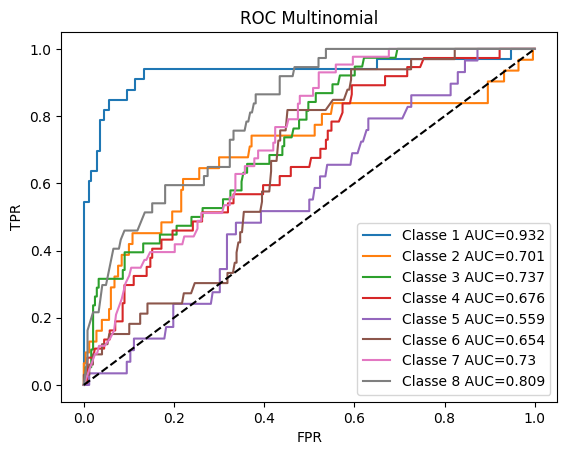

In [17]:
for i in range(n_classes):

    fpr,tpr,_ = roc_curve(
        y_bin[:,i],
        pred_prob[:, i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label="Classe "+str(classes[i])+" AUC="+str(round(roc_auc,3))
    )

plt.plot([0,1],[0,1],"k--")

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Multinomial")

plt.show()

In [18]:
roc = roc_auc_score(
    y_bin,
    pred_prob,
    multi_class="ovr"
)

print("ROC AUC:",roc)

ROC AUC: 0.7247534173733762


In [26]:
coef = pd.DataFrame(
    modelo.coef_,
    columns=X.columns,
    index=modelo.classes_
)

coef

,nao_vacinados,vacinados_parcialmente,totalmente_vacinados
1,0.117219,-0.722020,-0.258491
2,0.022128,0.449619,-0.011886
3,0.026535,0.331517,0.107484
4,0.003451,0.235198,0.122015
5,0.000730,0.009019,0.081362
6,-0.014196,0.017439,0.070508
7,-0.063138,-0.069956,-0.090026
8,-0.092729,-0.250817,-0.020966


In [27]:
probs = modelo.predict_proba(X_test)

prob_df = pd.DataFrame(
    probs,
    columns=modelo.classes_
)

prob_df

,1,2,3,4,5,6,7,8
0,0.046436,0.345747,0.273823,0.154967,0.104177,0.066632,0.006328,0.001891
1,0.010416,0.126805,0.085855,0.128369,0.161851,0.175395,0.151658,0.159653
2,0.650736,0.097742,0.120109,0.053931,0.051966,0.024347,0.000925,0.000242
3,0.427751,0.121634,0.080426,0.077400,0.125009,0.098857,0.043816,0.025106
4,0.040472,0.075729,0.035324,0.058807,0.110276,0.129428,0.268827,0.281136
...,...,...,...,...,...,...,...,...
276,0.014167,0.142151,0.186764,0.212404,0.209806,0.172155,0.032014,0.030539
277,0.047166,0.080249,0.037598,0.061164,0.114384,0.132260,0.261589,0.265590
278,0.008706,0.212614,0.130767,0.158211,0.156948,0.159186,0.098746,0.074822
279,0.003835,0.109522,0.137086,0.200975,0.204547,0.197788,0.063013,0.083234


Agora temos probabilidade direta de cada classe.

In [28]:
pred = modelo.predict(X_test)

pred

array([2, 6, 1, 1, 8, 1, 6, 5, 5, 6, 1, 6, 3, 6, 4, 2, 4, 5, 1, 3, 8, 8,
       6, 6, 3, 8, 7, 7, 1, 3, 8, 3, 7, 8, 4, 2, 8, 1, 8, 1, 4, 2, 8, 8,
       7, 6, 8, 3, 8, 2, 3, 5, 1, 8, 8, 2, 8, 7, 6, 8, 5, 2, 2, 8, 1, 8,
       6, 1, 6, 8, 8, 7, 5, 8, 1, 1, 4, 2, 3, 1, 7, 8, 3, 2, 5, 6, 1, 5,
       8, 8, 1, 3, 5, 8, 1, 2, 3, 4, 8, 8, 7, 8, 1, 5, 5, 3, 5, 6, 8, 7,
       8, 3, 2, 4, 2, 5, 8, 8, 3, 7, 3, 2, 2, 3, 6, 1, 7, 3, 2, 8, 8, 2,
       1, 6, 8, 8, 2, 5, 5, 2, 8, 2, 8, 4, 8, 6, 2, 1, 4, 6, 8, 8, 8, 8,
       5, 8, 3, 1, 2, 8, 4, 5, 8, 8, 2, 3, 6, 2, 2, 8, 8, 8, 8, 8, 3, 3,
       5, 4, 5, 2, 5, 5, 8, 8, 3, 1, 2, 1, 4, 7, 1, 4, 1, 8, 2, 8, 2, 5,
       7, 1, 8, 2, 4, 2, 4, 6, 2, 2, 8, 5, 6, 7, 2, 5, 2, 1, 1, 2, 1, 7,
       2, 1, 8, 8, 8, 8, 8, 2, 2, 8, 8, 3, 6, 8, 5, 3, 8, 2, 8, 1, 2, 3,
       8, 4, 8, 8, 1, 8, 7, 3, 2, 2, 1, 4, 5, 6, 4, 2, 8, 8, 8, 8, 8, 8,
       5, 5, 8, 5, 6, 7, 4, 8, 8, 3, 5, 2, 4, 8, 2, 5, 8], dtype=int64)

In [29]:
confusion_matrix(y_test, pred)

array([[26,  2,  0,  1,  1,  1,  2,  0],
       [ 4, 14,  2,  2,  2,  0,  4,  3],
       [ 1,  9, 10,  2,  8,  3,  0,  5],
       [ 1,  6,  9,  7,  0,  1,  2, 11],
       [ 1,  8,  3,  2,  2,  2,  1, 10],
       [ 1,  2,  3,  3,  6,  4,  0, 14],
       [ 0,  4,  0,  2,  7,  8,  3, 19],
       [ 0,  1,  0,  1,  5,  4,  5, 21]], dtype=int64)

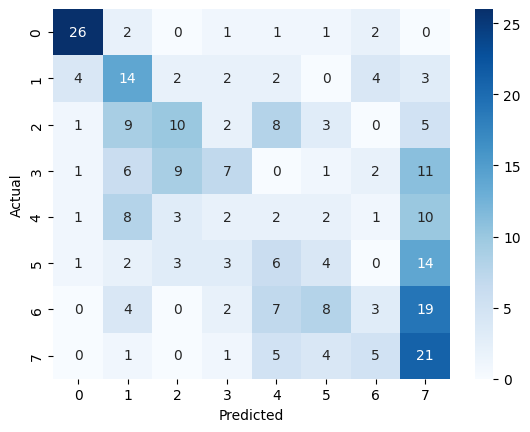

In [30]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       0.76      0.79      0.78        33
           2       0.30      0.45      0.36        31
           3       0.37      0.26      0.31        38
           4       0.35      0.19      0.25        37
           5       0.06      0.07      0.07        29
           6       0.17      0.12      0.14        33
           7       0.18      0.07      0.10        43
           8       0.25      0.57      0.35        37

    accuracy                           0.31       281
   macro avg       0.31      0.31      0.29       281
weighted avg       0.31      0.31      0.29       281

